In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import make_blobs

In [ ]:
X, _ = make_blobs(n_samples=30, centers=3, cluster_std=10, random_state=42)

In [ ]:
clustering = AgglomerativeClustering(n_clusters=3)
labels = clustering.fit_predict(X)

In [ ]:
agg = AgglomerativeClustering(
    distance_threshold=0,
    n_clusters=None,
    compute_distances=True
)
agg.fit(X)

AgglomerativeClustering(compute_distances=True, distance_threshold=0,
                        n_clusters=None)

In [ ]:
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)

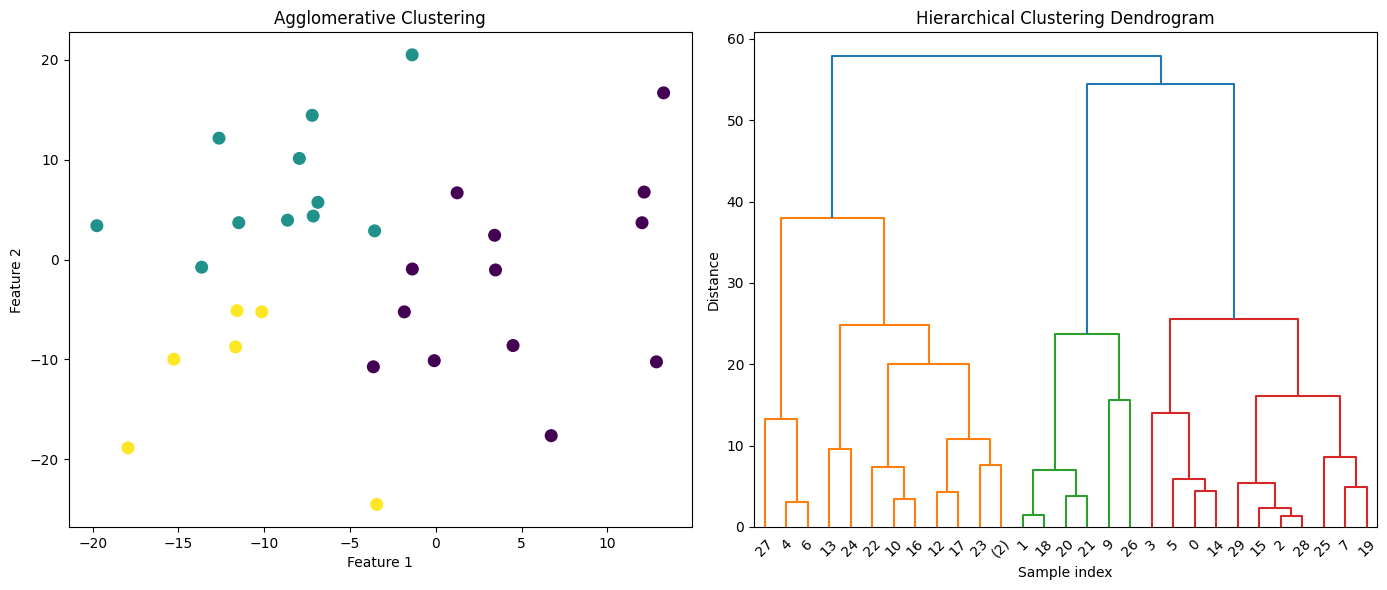

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=70)
ax1.set_title("Agglomerative Clustering")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

plt.sca(ax2)
plot_dendrogram(agg, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

In [8]:
# Python implementation
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [9]:
iris = load_iris()
X = iris.data
y = iris.target

In [11]:
linked = linkage(X,method='ward')

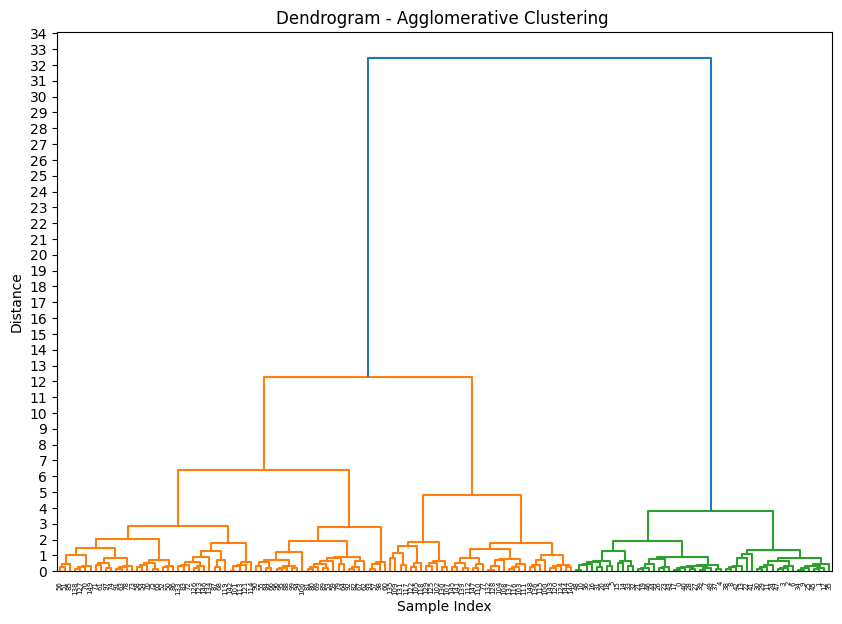

In [31]:
# creating a dendogram
plt.figure(figsize=(10,7))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram - Agglomerative Clustering ')
plt.xlabel('Sample Index')
plt.yticks(range(0,35))
plt.ylabel('Distance')
plt.show()

In [32]:
# determining a threshold value from y to cut the dendogram and form cluster
threshold  = 10
cluster = fcluster(linked,threshold,criterion = 'distance')
print(cluster)
clusters= []

#how many clusters
for c in cluster:
  if c not in clusters:
    clusters.append(c)
print(len(clusters))

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 3 2 2 2 2 3 2 2 2 2
 2 2 3 3 2 2 2 2 3 2 3 2 3 2 2 3 3 2 2 2 2 2 3 3 2 2 2 3 2 2 2 3 2 2 2 3 2
 2 3]
3


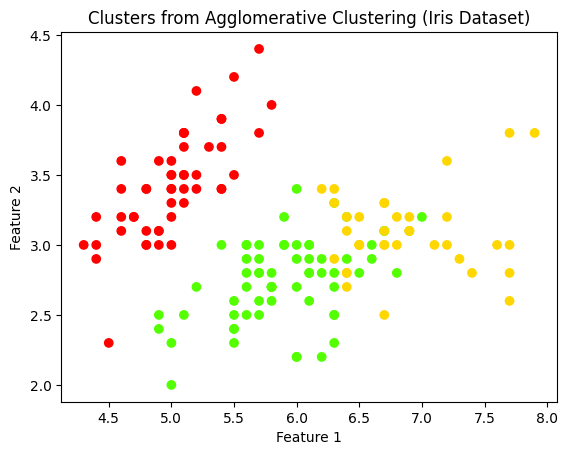

In [33]:
plt.scatter(X[:, 0], X[:, 1], c=cluster, cmap='prism')
plt.title('Clusters from Agglomerative Clustering (Iris Dataset)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

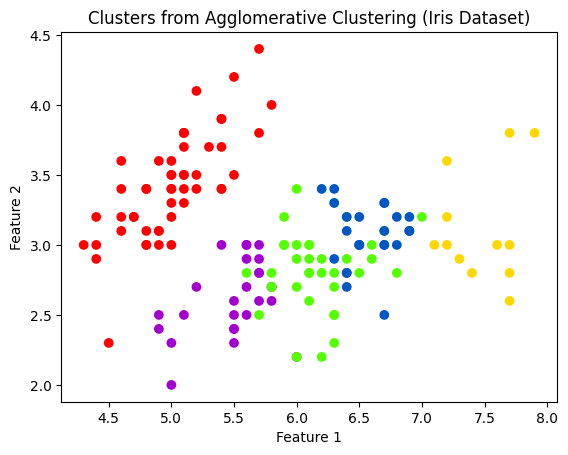

In [34]:
threshold = 4
cluster = fcluster(linked, threshold, criterion='distance')
plt.scatter(X[:, 0], X[:, 1], c=cluster, cmap='prism')
plt.title('Clusters from Agglomerative Clustering (Iris Dataset)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [38]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [39]:
# Perform PCA for dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [40]:
# Apply K-means to divide the cluster
kmeans = KMeans(n_clusters=3, random_state=42,n_init=10)
labels = kmeans.fit_predict(X_pca)

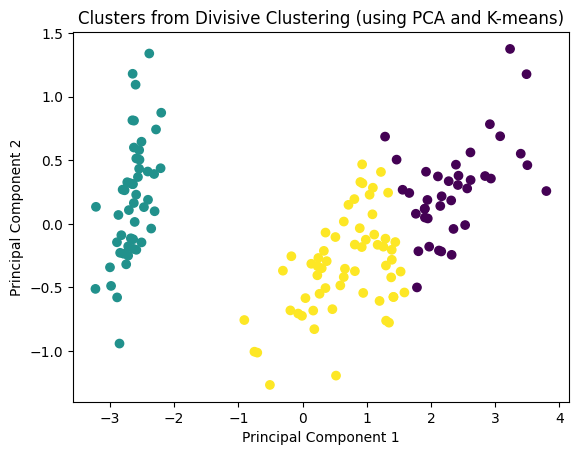

In [41]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis')
plt.title('Clusters from Divisive Clustering (using PCA and K-means)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

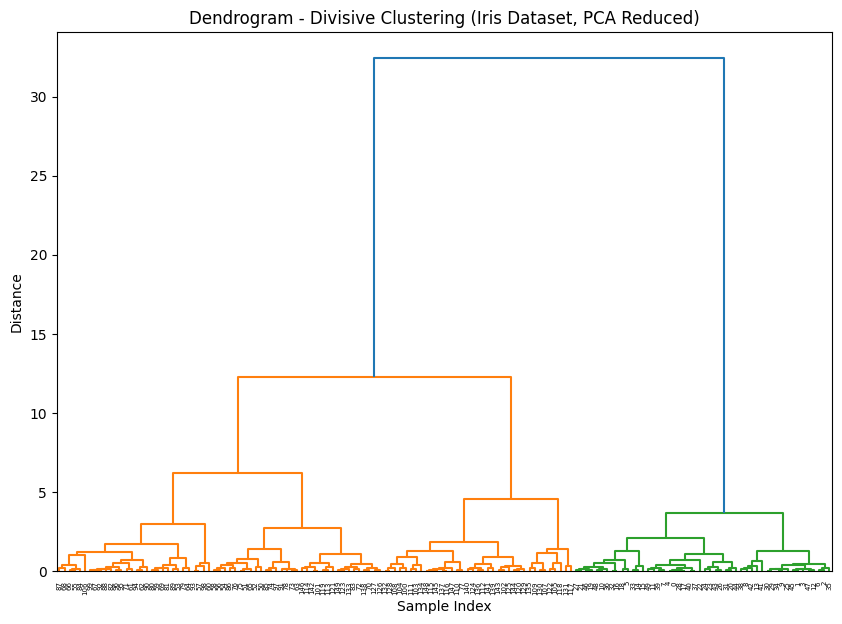

In [42]:
# Perform Agglomerative Clustering on PCA results to visualize hierarchical splitting
linked = linkage(X_pca, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram - Divisive Clustering (Iris Dataset, PCA Reduced)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()